# Checkpoint 2: Project Scope, Methods, and Initial/Expanded Analysis

This notebook contains the second checkpoint material from the original combined project notebook. It focuses on the Electronics portion of the Market Bias dataset and develops the three research questions around pattern mining, clustering, and causal/fairness analysis.

## Setup and Data Loading

Run this first so the checkpoint can be executed independently of Checkpoint 1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# This notebook was developed in Google Colab.
# Recommended repo layout:
# data/df_electronics.csv
# data/df_modcloth.csv  (only needed for Checkpoint 1)
DATA_DIR = Path("data")

# If running in Colab and the data files are not in the repo, mount Google Drive.
if not (DATA_DIR / "df_electronics.csv").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_DIR = Path("/content/drive/MyDrive/CSCE676 Project Data")
    except Exception:
        print("Could not mount Google Drive. Make sure the data files are available in ./data or update DATA_DIR.")

electronics_path = DATA_DIR / "df_electronics.csv"
df_elec = pd.read_csv(electronics_path)


print("Electronics shape:", df_elec.shape)

#**Project Checkpoint 2**

# **Project Scope**
- Dataset: Market Bias Dataset (Electronics)
- Course techniques: Frequent itemsets, Clustering, Graph Mining
- External techniques: Causal Modeling, Fairness Metrics

**Research Questions:**

# RQ-to-Method Mapping Table

| Research Question (RQ) | Data Mining Task Type | Course Algorithm(s) | External Algorithm(s) | Evaluation Criteria |
|------------------------|--------------------|------------------|---------------------|------------------|
| **RQ1:** Do certain combinations of product attributes and <br>model gender frequently co-occur with high or low ratings? | Frequent Itemset Mining / Association Rule Mining | Apriori<br>FP-Growth | None | Support<br>Confidence<br>Lift<br>Interpretability<br>Stability under varying support thresholds |
| **RQ2:** Do distinct clusters of ratings emerge based on <br>product attributes and model gender, and do these clusters reflect systematic rating bias? | Clustering | K-Means<br>Hierarchical Clustering | None | Silhouette Score<br>Within-cluster variance<br>Cluster interpretability<br>Distribution of rating across clusters |
| **RQ3:** Does the gender of the product model causally <br>influence product ratings after controlling for category, brand, and year? | Causal Inference / Fairness Analysis | None | Linear/Logistic Regression with controls<br>Propensity Score Matching<br>Average Treatment Effect estimation | Statistical significance (p-values)<br>Effect size<br>Average Treatment Effect<br>Fairness metrics (demographic parity difference, mean rate gap) |estimation | Statistical significance (p-values), Effect size, Average Treatment Effect, fairness metrics (demographic parity difference, mean rate gap) |

**Rating Distribution**


Rating Summary:
count    1.292954e+06
mean     4.051482e+00
std      1.379732e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


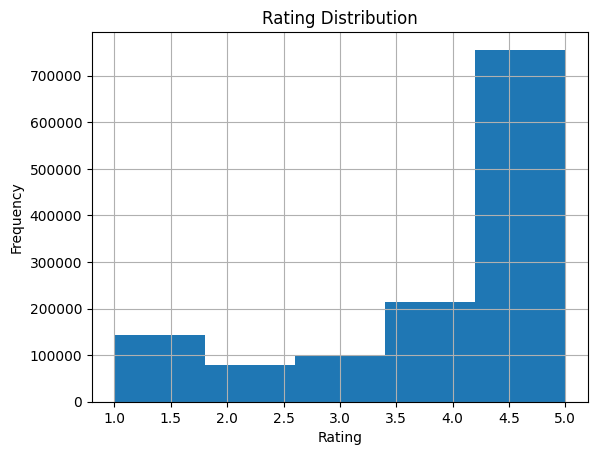


Rating Proportions:
rating
1.0    0.111183
2.0    0.060828
3.0    0.077830
4.0    0.165641
5.0    0.584518
Name: proportion, dtype: float64


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rating summary
print("\nRating Summary:")
print(df_elec["rating"].describe())

# Histogram
plt.figure()
df_elec["rating"].hist(bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# Rating proportions
print("\nRating Proportions:")
print(df_elec["rating"].value_counts(normalize=True).sort_index())

**Model Gender Distribution**

In [27]:
print("\nModel Gender Distribution:")
print(df_elec["model_attr"].value_counts())
print("\nModel Gender Percentage:")
print(df_elec["model_attr"].value_counts(normalize=True) * 100)


Model Gender Distribution:
model_attr
Female         481171
Male           429715
Female&Male    382068
Name: count, dtype: int64

Model Gender Percentage:
model_attr
Female         37.214858
Male           33.235134
Female&Male    29.550007
Name: proportion, dtype: float64


**User Gender Distribution**

In [28]:
print("\nUser Gender Distribution:")
print(df_elec["user_attr"].value_counts(dropna=False))


User Gender Distribution:
user_attr
NaN       1118830
Male        87424
Female      86700
Name: count, dtype: int64


**Cross-Tab: Rating x Model Gender**


Mean Rating by Model Gender:
model_attr
Female         4.066153
Female&Male    4.084244
Male           4.005925
Name: rating, dtype: float64

Rating Distribution by Model Gender:
rating            1.0       2.0       3.0       4.0       5.0
model_attr                                                   
Female       0.111993  0.058786  0.074732  0.160051  0.594437
Female&Male  0.108266  0.057634  0.073811  0.162167  0.598121
Male         0.112870  0.065955  0.084870  0.174988  0.561316


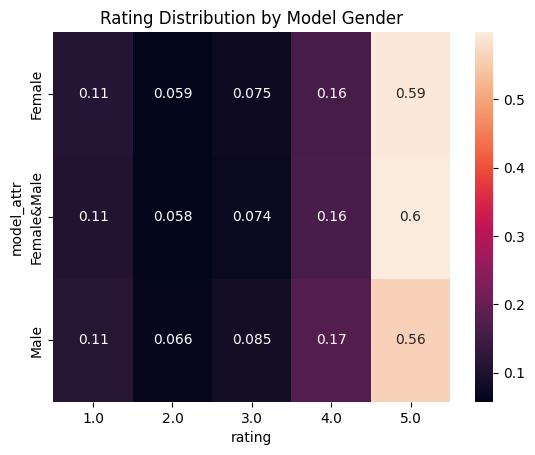

In [29]:
# Mean rating by model gender
print("\nMean Rating by Model Gender:")
print(df_elec.groupby("model_attr")["rating"].mean())

# Full distribution
rating_gender_ct = pd.crosstab(df_elec["model_attr"], df_elec["rating"], normalize="index")
print("\nRating Distribution by Model Gender:")
print(rating_gender_ct)

# Heatmap
plt.figure()
sns.heatmap(rating_gender_ct, annot=True)
plt.title("Rating Distribution by Model Gender")
plt.show()

**Cross-Tab: Rating x Category**


Mean Rating by Category:
category
Accessories & Supplies     4.257784
Camera & Photo             4.129795
Portable Audio & Video     4.122996
Computers & Accessories    4.101871
Car Electronics & GPS      4.062897
Home Audio                 4.047410
Headphones                 3.895877
Television & Video         3.841626
Security & Surveillance    3.770313
Wearable Technology        3.494224
Name: rating, dtype: float64


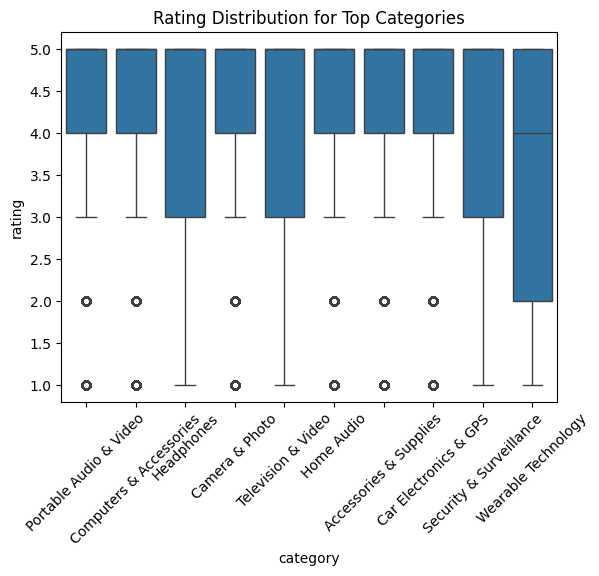

In [30]:
print("\nMean Rating by Category:")
print(df_elec.groupby("category")["rating"].mean().sort_values(ascending=False))

# Top 10 categories by count
top_categories = df_elec["category"].value_counts().head(10).index
df_top = df_elec[df_elec["category"].isin(top_categories)]

plt.figure()
sns.boxplot(data=df_top, x="category", y="rating")
plt.xticks(rotation=45)
plt.title("Rating Distribution for Top Categories")
plt.show()

**Model Gender Distribution Within Category**


Model Gender Distribution by Category:
model_attr                 Female  Female&Male      Male
category                                                
Accessories & Supplies   0.515221     0.187625  0.297154
Camera & Photo           0.419747     0.239457  0.340795
Car Electronics & GPS    0.432416     0.224493  0.343090
Computers & Accessories  0.437245     0.210700  0.352055
Headphones               0.266423     0.339534  0.394043
Home Audio               0.310255     0.485223  0.204522
Portable Audio & Video   0.283679     0.523854  0.192467
Security & Surveillance  0.396817     0.222932  0.380252
Television & Video       0.343014     0.439748  0.217238
Wearable Technology      0.245208     0.335623  0.419170


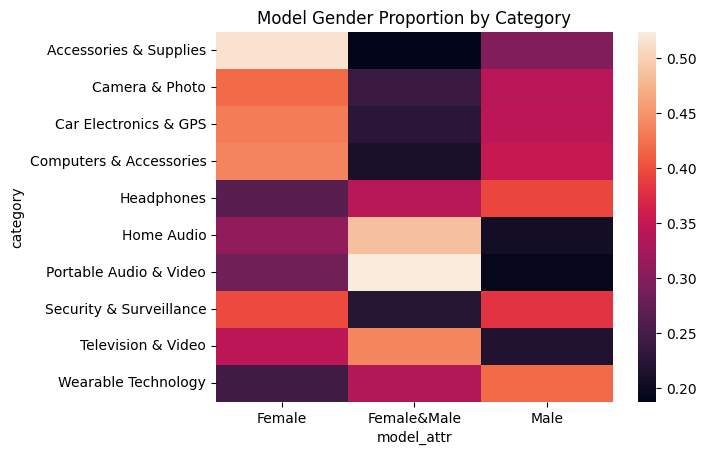

In [31]:
gender_category = pd.crosstab(df_elec["category"], df_elec["model_attr"], normalize="index")
print("\nModel Gender Distribution by Category:")
print(gender_category.head(10))

plt.figure()
sns.heatmap(gender_category.head(15), annot=False)
plt.title("Model Gender Proportion by Category")
plt.show()

Create High / Low Rating Variable (For Mining and Fairness)

In [32]:
df_elec["rating_label"] = pd.cut(
    df_elec["rating"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Medium", "High"]
)

print(df_elec["rating_label"].value_counts())

rating_label
High      969921
Low       222403
Medium    100630
Name: count, dtype: int64


**Brand Sparsity Check**

In [33]:
print("\nTop Brands:")
print(df_elec["brand"].value_counts().head(15))

print("\nNumber of Unique Brands:", df_elec["brand"].nunique())


Top Brands:
brand
Bose          29222
Logitech      29203
Sony          20360
Mpow          17477
EldHus        16530
Sennheiser    13322
Fujifilm      12245
TaoTronics    12125
Etre Jeune    11753
Pyle          11606
JLAB          10079
Skullcandy    10014
Kodak          8701
Linksys        8288
Jabra          7417
Name: count, dtype: int64

Number of Unique Brands: 50


**Temporal Distribution**

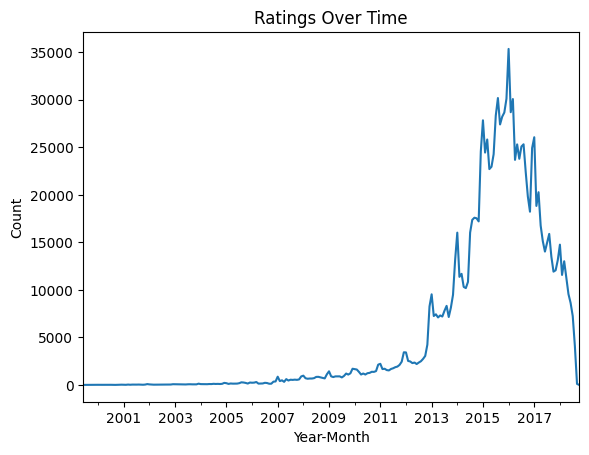

In [34]:
df_elec["timestamp"] = pd.to_datetime(df_elec["timestamp"])

# Ratings over time
df_elec["year_month"] = df_elec["timestamp"].dt.to_period("M")

monthly_counts = df_elec["year_month"].value_counts().sort_index()

plt.figure()
monthly_counts.plot()
plt.title("Ratings Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Count")
plt.show()

# **Motivation and Feasibility**

Motivation

Exploratory analysis reveals a heavily right-skewed rating distribution, with over 58% of ratings equal to 5. Additionally, a naïve comparison shows a small but consistent rating gap between male and female product models (≈0.06). However, category-level rating differences are substantially larger (up to 0.77), and model gender distribution varies significantly across categories, indicating potential confounding. These findings motivate a deeper structural and causal investigation of whether model gender influences ratings beyond category effects.

Non-Triviality

The problem is non-trivial because rating imbalance and category confounding obscure simple interpretations. Frequent itemset mining captures multi-attribute interactions, clustering reveals latent structural groupings, and causal modeling is required to separate correlation from causal influence.

Feasibility

The dataset size (1.29M observations) and limited attribute dimensionality make Apriori/FP-Growth, K-Means clustering, and regression-based causal modeling computationally feasible. Balanced gender representation ensures stable estimation in causal models.

# **Methodological Planning**

RQ1 – Association Between Model Gender and Ratings

(Frequent Itemset Mining – Course)

- Course algorithms: Apriori, FP-Growth

- External algorithms: None

- Evaluation: Support, confidence, lift (primary metric due to rating imbalance), rule interpretability

- Baselines: High-support-only mining (compare support-ranked vs lift-ranked rules)

- Feasibility check: Use FP-Growth for scalability (1.29M rows), restrict to top-k brands to avoid sparsity

RQ2 – Structural Segmentation of Products

(Clustering – Course)

- Course algorithms: K-Means, Hierarchical Clustering

- External algorithms: None

- Evaluation: Silhouette score, within-cluster variance, cluster interpretability (rating mean + gender distribution per cluster)

- Baselines:

  - Clustering without model_gender feature

  - Clustering without rating feature

- Feasibility check: One-hot encoding manageable (≈50 brands, ~10 categories), MiniBatch K-Means if needed

RQ3 – Causal Effect of Model Gender on Ratings

(Causal Modeling + Fairness – External)

- Course algorithms: None

- External algorithms: Linear regression with controls, Logistic regression, Propensity Score Matching

- Evaluation:

  - Coefficient magnitude

  - Statistical significance

  - Confidence intervals

  - Average Treatment Effect (ATE)

  - Demographic parity difference

- Baselines:

   - Naïve mean difference (uncontrolled)

   - Regression without covariates

- Feasibility check: Balanced gender distribution (~37% / 33% / 30%) ensures stable estimation; category and brand controls reduce confounding

# **Initial Method Runs**

Frequent Itemset Mining

For frequent itemset mining, I chose to use the FP-Growth algorithm instead of Apriori because it is more computationally efficient on large datasets, as it avoids generating excessive candidate itemsets. I selected the features model_attr, brand, category, and rating because they represent meaningful product attributes that may co-occur in patterns. I sampled 100,000 rows to balance computational efficiency with sufficient data coverage, and converted all values to strings so they could be treated as categorical items in transactions. I set the minimum support to 0.01 to filter out very rare combinations while still capturing useful patterns. For rule generation, I used lift as the evaluation metric with a threshold of 1 to focus on associations that are stronger than random chance, and sorted results by lift to highlight the most meaningful relationships.

In [35]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
# Select columns for mining
cols = ["model_attr", "brand", "category", "rating"]
df_elec_sample = df_elec.sample(100000, random_state=42)
# Convert each row into a list of items
transactions = df_elec_sample[cols].astype(str).values.tolist()

# Encode transactions
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_transactions = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction matrix shape:", df_transactions.shape)

Transaction matrix shape: (100000, 69)


In [36]:
freq_items = fpgrowth(
    df_transactions,
    min_support=0.01,   # adjust later
    use_colnames=True
)

print(freq_items.head())

   support                  itemsets
0  0.37204                  (Female)
1  0.12120  (Accessories & Supplies)
2  0.07814                     (3.0)
3  0.01268                  (EldHus)
4  0.74407                     (nan)


In [37]:
rules = association_rules(
    freq_items,
    metric="lift",
    min_threshold=1
)

rules = rules.sort_values("lift", ascending=False)

print(rules[["antecedents","consequents","support","confidence","lift"]].head(10))

                         antecedents                      consequents  support  confidence      lift
513                           (Mpow)        (Headphones, Female&Male)  0.01024    0.768769  8.172305
508        (Headphones, Female&Male)                           (Mpow)  0.01024    0.108855  8.172305
313                       (Logitech)  (Computers & Accessories, Male)  0.01136    0.529110  6.076141
312  (Computers & Accessories, Male)                       (Logitech)  0.01136    0.130455  6.076141
311                 (Logitech, Male)        (Computers & Accessories)  0.01136    0.999120  4.025628
314        (Computers & Accessories)                 (Logitech, Male)  0.01136    0.045771  4.025628
316                  (5.0, Logitech)        (Computers & Accessories)  0.01255    0.996823  4.016370
321        (Computers & Accessories)                  (5.0, Logitech)  0.01255    0.050566  4.016370
304                       (Logitech)        (Computers & Accessories)  0.02138    0.995808 

Clustering

For clustering, I used K-Means as a baseline algorithm because it is simple, efficient, and works well for exploratory analysis on large datasets. I sampled 10,000 rows to reduce computational cost while preserving enough structure in the data. Since K-Means requires numeric input, I applied one-hot encoding to the categorical features (category, brand, model_attr) and standardized the rating feature so it would be on a comparable scale. I combined these into a single feature matrix to ensure both product attributes and rating information influenced the clustering. I selected 5 clusters as an initial choice to capture potential groupings without overcomplicating the model, and evaluated the result using the silhouette score to measure how well-separated the clusters are.

In [38]:
# Take a 10,000 sample
df_sample = df_elec.sample(n=10000, random_state=42)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

# Select features
features = df_sample[["category", "brand", "model_attr", "rating"]]

# Create encoder
encoder = OneHotEncoder(sparse_output=False)

# Encode categorical variables
encoded = encoder.fit_transform(features[["category", "brand", "model_attr"]])

# Scale rating
rating_scaled = StandardScaler().fit_transform(features[["rating"]])

# Combine into feature matrix
X = np.hstack([encoded, rating_scaled])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (10000, 65)


In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X)

df_sample["cluster"] = clusters

print("Silhouette Score:", silhouette_score(X, clusters))

Silhouette Score: 0.21236546046419813


In [40]:
print("\nCluster Rating Mean:")
print(df_sample.groupby("cluster")["rating"].mean())

print("\nCluster Gender Distribution:")
print(pd.crosstab(df_sample["cluster"], df_sample["model_attr"], normalize="index"))


Cluster Rating Mean:
cluster
0    1.723822
1    4.791265
2    4.767869
3    4.643868
4    4.663088
Name: rating, dtype: float64

Cluster Gender Distribution:
model_attr    Female  Female&Male      Male
cluster                                    
0           0.371291     0.277923  0.350785
1           0.267194     0.381362  0.351444
2           0.681416     0.139551  0.179033
3           0.250472     0.379245  0.370283
4           0.408753     0.251032  0.340215


Regression / Causal Modeling

For regression, I used an OLS model to estimate the relationship between product attributes and rating, with a specific focus on the effect of a female model indicator. I created a binary variable (female_model) to isolate this effect and included categorical controls for category and brand using C() to account for differences across product types and brands. This helps reduce confounding by ensuring the estimated effect of the model attribute is not driven by underlying category or brand differences. I chose OLS because it provides interpretable coefficients and serves as a straightforward baseline for causal-style analysis, allowing me to quantify how the presence of a female model is associated with changes in rating while holding other factors constant.

In [41]:
df_reg = df_elec.copy()

df_reg["female_model"] = (df_reg["model_attr"] == "Female").astype(int)

In [42]:
import statsmodels.formula.api as smf

model = smf.ols(
    "rating ~ female_model + C(category) + C(brand)",
    data=df_reg
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     241.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:45:29   Log-Likelihood:            -5.6638e+05
No. Observations:              331120   AIC:                         1.133e+06
Df Residuals:                  331060   BIC:                         1.134e+06
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [43]:
import pandas as pd
import numpy as np

# Make sure model_attr and rating exist
df = df_elec.copy()

# Keep only the model groups you care about
df = df[df["model_attr"].isin(["Female", "Female&Male", "Male"])].copy()

# Mean rating by model group
mean_ratings = df.groupby("model_attr")["rating"].mean().sort_values(ascending=False)
print("Mean Rating by Model Gender:")
print(mean_ratings)
print()

# Rating distribution by model group
rating_dist = pd.crosstab(df["model_attr"], df["rating"], normalize="index")
print("Rating Distribution by Model Gender:")
print(rating_dist)
print()

# 5-star rate by model group
five_star_rate = (
    df.assign(is_5_star=(df["rating"] == 5).astype(int))
      .groupby("model_attr")["is_5_star"]
      .mean()
      .sort_values(ascending=False)
)
print("5-Star Rate by Model Gender:")
print(five_star_rate)
print()

# Raw gap examples
female_mean = mean_ratings.get("Female", np.nan)
male_mean = mean_ratings.get("Male", np.nan)
both_mean = mean_ratings.get("Female&Male", np.nan)

print(f"Raw Female - Male mean gap: {female_mean - male_mean:.4f}")
print(f"Raw Female&Male - Male mean gap: {both_mean - male_mean:.4f}")

Mean Rating by Model Gender:
model_attr
Female&Male    4.084244
Female         4.066153
Male           4.005925
Name: rating, dtype: float64

Rating Distribution by Model Gender:
rating            1.0       2.0       3.0       4.0       5.0
model_attr                                                   
Female       0.111993  0.058786  0.074732  0.160051  0.594437
Female&Male  0.108266  0.057634  0.073811  0.162167  0.598121
Male         0.112870  0.065955  0.084870  0.174988  0.561316

5-Star Rate by Model Gender:
model_attr
Female&Male    0.598121
Female         0.594437
Male           0.561316
Name: is_5_star, dtype: float64

Raw Female - Male mean gap: 0.0602
Raw Female&Male - Male mean gap: 0.0783


In [44]:
import statsmodels.formula.api as smf

df_reg = df_elec.copy()

# Keep only needed columns
df_reg = df_reg[["rating", "model_attr", "category", "brand"]].copy()

# Keep only rows with known values
df_reg = df_reg.dropna(subset=["rating", "model_attr", "category", "brand"])

# Restrict model groups
df_reg = df_reg[df_reg["model_attr"].isin(["Female", "Female&Male", "Male"])].copy()

# Optional: reduce sparsity by keeping only top brands
top_brands = df_reg["brand"].value_counts().head(50).index
df_reg = df_reg[df_reg["brand"].isin(top_brands)].copy()

print("Regression sample size:", len(df_reg))
print(df_reg["model_attr"].value_counts())
print()

# Baseline category for model_attr will be alphabetical unless you force it.
# Here we force Male as the reference group so coefficients are easy to interpret.
df_reg["model_attr"] = pd.Categorical(
    df_reg["model_attr"],
    categories=["Male", "Female", "Female&Male"],
    ordered=False
)

model = smf.ols(
    "rating ~ C(model_attr, Treatment(reference='Male')) + C(category) + C(brand)",
    data=df_reg
).fit()

print(model.summary())

Regression sample size: 331120
model_attr
Female         116258
Female&Male    109528
Male           105334
Name: count, dtype: int64

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     243.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:45:36   Log-Likelihood:            -5.6620e+05
No. Observations:              331120   AIC:                         1.133e+06
Df Residuals:                  331059   BIC:                         1.133e+06
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                                                                coef    std

In [45]:
import pandas as pd

# Copy and keep only relevant model groups
df = df_elec.copy()
df = df[df["model_attr"].isin(["Male", "Female", "Female&Male"])].copy()

# -----------------------------
# 1. Dataset size
# -----------------------------
n_reviews = len(df)
print(f"Amazon Electronics Dataset (~{n_reviews:,} reviews)")

# -----------------------------
# 2. Rating distribution
# -----------------------------
rating_counts = (
    df["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)

rating_counts["percent"] = rating_counts["count"] / rating_counts["count"].sum()

print("\nRating Distribution:")
print(rating_counts)

# -----------------------------
# 3. Mean rating by model gender
# -----------------------------
mean_rating_by_gender = (
    df.groupby("model_attr")["rating"]
    .mean()
    .reindex(["Male", "Female", "Female&Male"])
    .reset_index(name="mean_rating")
)

print("\nMean Rating by Model Gender:")
print(mean_rating_by_gender)

# -----------------------------
# 4. 5-star rate by model gender
# -----------------------------
five_star_rate_by_gender = (
    df.assign(is_5_star=(df["rating"] == 5).astype(int))
    .groupby("model_attr")["is_5_star"]
    .mean()
    .reindex(["Male", "Female", "Female&Male"])
    .reset_index(name="five_star_rate")
)

print("\n5-Star Rate by Model Gender:")
print(five_star_rate_by_gender)

# -----------------------------
# 5. Optional: combined summary table
# -----------------------------
slide_summary = mean_rating_by_gender.merge(
    five_star_rate_by_gender,
    on="model_attr"
)

print("\nSlide Summary:")
print(slide_summary)

Amazon Electronics Dataset (~1,292,954 reviews)

Rating Distribution:
   rating   count   percent
0     1.0  143755  0.111183
1     2.0   78648  0.060828
2     3.0  100630  0.077830
3     4.0  214166  0.165641
4     5.0  755755  0.584518

Mean Rating by Model Gender:
    model_attr  mean_rating
0         Male     4.005925
1       Female     4.066153
2  Female&Male     4.084244

5-Star Rate by Model Gender:
    model_attr  five_star_rate
0         Male        0.561316
1       Female        0.594437
2  Female&Male        0.598121

Slide Summary:
    model_attr  mean_rating  five_star_rate
0         Male     4.005925        0.561316
1       Female     4.066153        0.594437
2  Female&Male     4.084244        0.598121


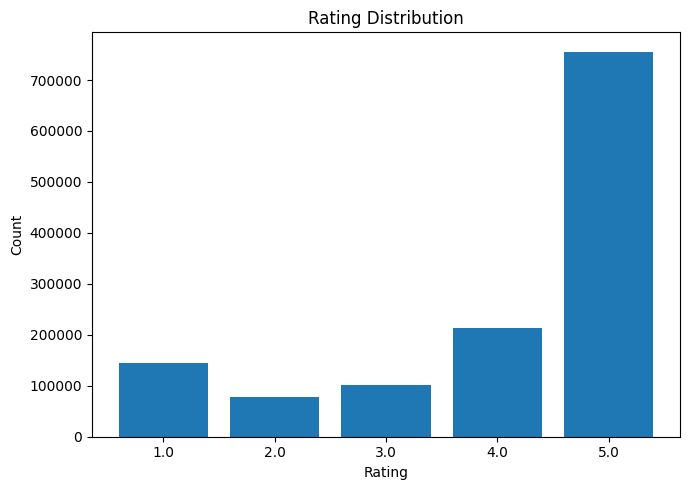

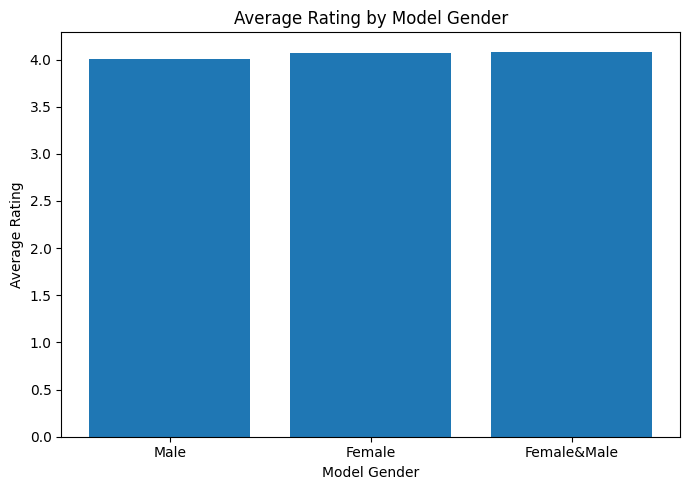

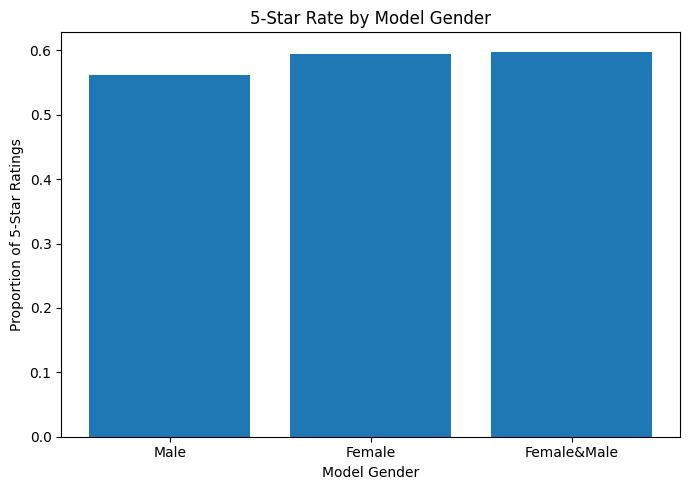

In [46]:
import matplotlib.pyplot as plt

# -----------------------------
# Graph 1: Rating distribution
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(rating_counts["rating"].astype(str), rating_counts["count"])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# Graph 2: Mean rating by model gender
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(mean_rating_by_gender["model_attr"], mean_rating_by_gender["mean_rating"])
plt.title("Average Rating by Model Gender")
plt.xlabel("Model Gender")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

# -----------------------------
# Graph 3: 5-star rate by model gender
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(five_star_rate_by_gender["model_attr"], five_star_rate_by_gender["five_star_rate"])
plt.title("5-Star Rate by Model Gender")
plt.xlabel("Model Gender")
plt.ylabel("Proportion of 5-Star Ratings")
plt.tight_layout()
plt.show()

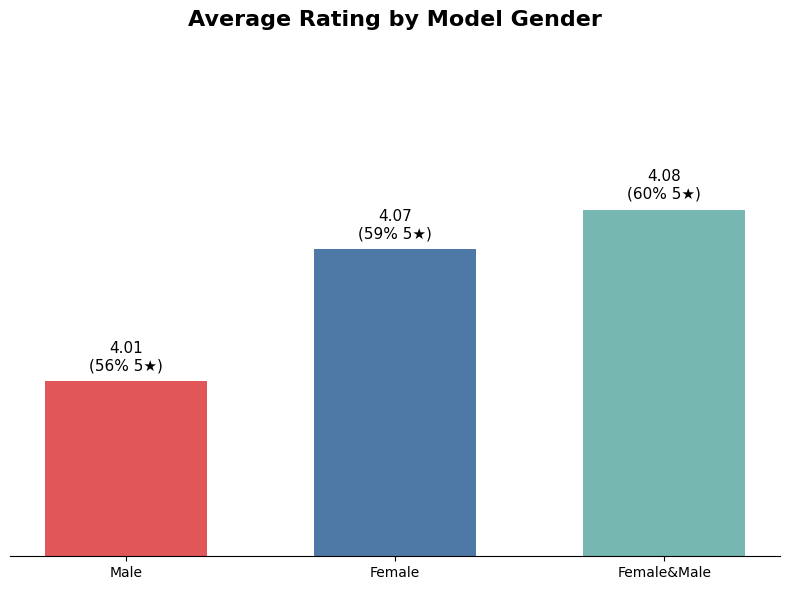

In [48]:
import matplotlib.pyplot as plt

# Prepare data
df = df_elec.copy()
df = df[df["model_attr"].isin(["Male", "Female", "Female&Male"])].copy()

mean_rating = (
    df.groupby("model_attr")["rating"]
    .mean()
    .reindex(["Male", "Female", "Female&Male"])
)

five_star_rate = (
    df.assign(is_5_star=(df["rating"] == 5).astype(int))
    .groupby("model_attr")["is_5_star"]
    .mean()
    .reindex(["Male", "Female", "Female&Male"])
)

# Modern color palette
colors = ["#E15759", "#4E79A7", "#76B7B2"]
# Male = red (highlight), Female = blue, Both = teal

plt.figure(figsize=(8,6))

bars = plt.bar(mean_rating.index, mean_rating.values, color=colors, width=0.6)

# Title
plt.title("Average Rating by Model Gender", fontsize=16, weight='bold')

# Remove clutter
ax = plt.gca()
ax.spines[['top','right','left']].set_visible(False)
ax.set_yticks([])

# Add value labels + 5-star rate
for bar, rating, five_star in zip(bars, mean_rating.values, five_star_rate.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        rating + 0.005,
        f"{rating:.2f}\n({five_star*100:.0f}% 5★)",
        ha='center',
        fontsize=11
    )

# Highlight annotation
plt.annotate(
    "Lower ratings",
    xy=(0, mean_rating["Male"]),
    xytext=(0, mean_rating["Male"] - 0.06),
    arrowprops=dict(arrowstyle="->", color="#E15759"),
    ha='center',
    fontsize=11,
    color="#E15759"
)

# Adjust limits for spacing
plt.ylim(mean_rating.min() - 0.08, mean_rating.max() + 0.08)

plt.tight_layout()
plt.show()

# In depth Pattern Mining

Prepare Data

In [49]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

df_pm = df[["model_attr", "category", "brand", "rating"]].dropna().copy()

# Keep top brands so the rules are readable and not too sparse
top_brands = df_pm["brand"].value_counts().head(25).index
df_pm = df_pm[df_pm["brand"].isin(top_brands)].copy()

# Create rating buckets
df_pm["rating_label"] = pd.cut(
    df_pm["rating"],
    bins=[0, 3, 4, 5],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print(df_pm["rating_label"].value_counts())
print(df_pm.shape)

rating_label
High      166452
Low        70070
Medium     49450
Name: count, dtype: int64
(285972, 5)


Build Transactions

In [50]:
# Sample for speed if needed
sample_n = min(120000, len(df_pm))
df_pm_sample = df_pm.sample(n=sample_n, random_state=42).copy()

transactions = df_pm_sample[["model_attr", "category", "brand", "rating_label"]].astype(str).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print(df_trans.shape)
df_trans.head()

(120000, 41)


,Accessories & Supplies,Apple,Bose,Camera & Photo,Canon,Car Electronics & GPS,Computers & Accessories,EldHus,Etre Jeune,Female,Female&Male,Fintie,Fujifilm,Garmin,Headphones,High,Home Audio,JLAB,Jabra,Kodak,Linksys,Logitech,Low,Male,Medium,Mpow,Neewer,Nikon,Panasonic,Philips,Polaroid,Portable Audio & Video,Pyle,Samsung,Security & Surveillance,Sennheiser,Skullcandy,Sony,TaoTronics,Television & Video,Wearable Technology
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
1,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


Frequent Itemsets + Rules

In [51]:
freq_items = fpgrowth(
    df_trans,
    min_support=0.01,
    use_colnames=True
)

rules = association_rules(
    freq_items,
    metric="lift",
    min_threshold=1.0
)

# Keep only rules whose consequence is rating-related
rules_rating = rules[
    rules["consequents"].apply(lambda x: any(label in x for label in ["High", "Medium", "Low"]))
].copy()

rules_rating = rules_rating.sort_values(["lift", "confidence"], ascending=False)

print(rules_rating[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

                           antecedents                             consequents   support  confidence       lift
525                           (Garmin)           (Car Electronics & GPS, High)  0.015092    0.595332  32.695580
524            (Car Electronics & GPS)                          (High, Garmin)  0.015092    0.467355  30.916527
1084                      (TaoTronics)         (Home Audio, Female&Male, High)  0.010750    0.250924  15.650142
1079         (Female&Male, TaoTronics)                      (Home Audio, High)  0.010750    0.342903  14.968470
1083         (Female&Male, Home Audio)                      (High, TaoTronics)  0.010750    0.404009  14.949446
817           (Accessories & Supplies)                  (Female, High, EldHus)  0.013883    0.235510  14.921456
812                   (Female, EldHus)          (Accessories & Supplies, High)  0.013883    0.539508  14.791166
1087                      (Home Audio)         (High, Female&Male, TaoTronics)  0.010750    0.268862  13

**Focus specifically on model gender**


Rules predicting high ratings

In [52]:
rules_high = rules_rating[
    rules_rating["consequents"].apply(lambda x: "High" in x)
].copy()

rules_high_gender = rules_high[
    rules_high["antecedents"].apply(lambda x: any(g in x for g in ["Male", "Female", "Female&Male"]))
].sort_values(["lift", "confidence"], ascending=False)

print("Top gender-related rules predicting HIGH ratings:")
print(rules_high_gender[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))

Top gender-related rules predicting HIGH ratings:
                            antecedents                      consequents   support  confidence       lift
1079          (Female&Male, TaoTronics)               (Home Audio, High)  0.010750    0.342903  14.968470
1083          (Female&Male, Home Audio)               (High, TaoTronics)  0.010750    0.404009  14.949446
812                    (Female, EldHus)   (Accessories & Supplies, High)  0.013883    0.539508  14.791166
810    (Female, Accessories & Supplies)                   (EldHus, High)  0.013883    0.370964  10.304560
1016      (Camera & Photo, Female&Male)                 (High, Fujifilm)  0.010008    0.230740   7.717046
369     (Computers & Accessories, Male)                 (Logitech, High)  0.028317    0.459562   7.504071
579            (Camera & Photo, Female)                    (Kodak, High)  0.011333    0.097226   6.846915
619   (Female, Computers & Accessories)                  (Linksys, High)  0.010550    0.090075   6.836

Rules predicting low ratings

In [53]:
rules_low = rules_rating[
    rules_rating["consequents"].apply(lambda x: "Low" in x)
].copy()

rules_low_gender = rules_low[
    rules_low["antecedents"].apply(lambda x: any(g in x for g in ["Male", "Female", "Female&Male"]))
].sort_values(["lift", "confidence"], ascending=False)

print("Top gender-related rules predicting LOW ratings:")
print(rules_low_gender[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))

Top gender-related rules predicting LOW ratings:
                         antecedents                               consequents   support  confidence       lift
392  (Computers & Accessories, Male)                           (Logitech, Low)  0.014742    0.239248  10.101958
390                 (Logitech, Male)            (Computers & Accessories, Low)  0.014742    0.278846   6.282677
234               (Headphones, Male)                         (Low, Skullcandy)  0.010400    0.065986   5.568469
683        (Headphones, Female&Male)                               (Low, Mpow)  0.013400    0.082293   4.959883
237               (Skullcandy, Male)                         (Headphones, Low)  0.010400    0.361949   3.501320
241                           (Male)             (Headphones, Low, Skullcandy)  0.010400    0.032964   2.803420
227                           (Male)                         (Low, Skullcandy)  0.010400    0.032964   2.781734
690                    (Female&Male)                   

Simple direct comparison by gender bucket

rating_label       Low    Medium      High
model_attr                                
Female        0.236702  0.167871  0.595427
Female&Male   0.232034  0.173449  0.594518
Male          0.268052  0.178126  0.553822


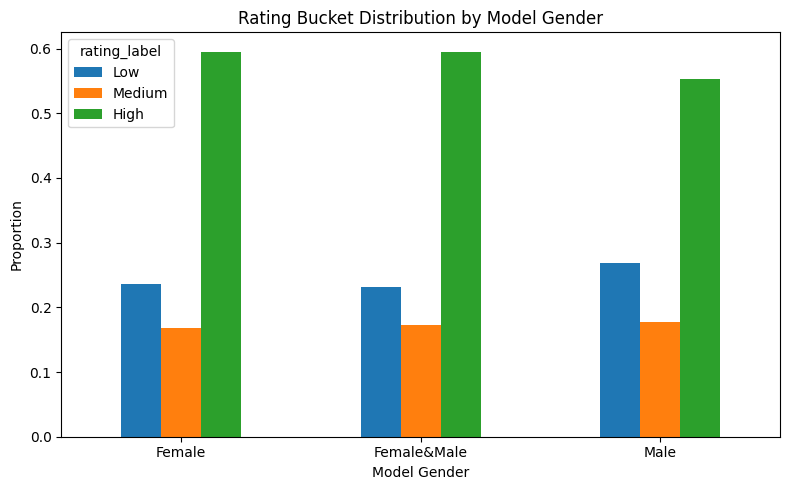

In [54]:
pm_summary = pd.crosstab(df_pm["model_attr"], df_pm["rating_label"], normalize="index")
print(pm_summary)

pm_summary.plot(kind="bar", figsize=(8,5))
plt.title("Rating Bucket Distribution by Model Gender")
plt.xlabel("Model Gender")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Pattern Mining Results
Pattern mining reveals that model gender appears in combinations of product attributes associated with rating outcomes, rather than acting independently. Female and mixed-gender products frequently occur in high-rating association rules, often alongside specific brands and categories, while male-presented products appear more often in rules linked to lower ratings. Importantly, these patterns are context-dependent, certain male-presented products still appear in high-rating combinations, indicating that the effect of model gender is not uniform but interacts with other product attributes. Overall, this suggests that model gender contributes to rating differences through its role within broader attribute combinations, providing evidence of subtle but systematic bias in how products are evaluated.

# In depth Clustering

Prepare features

In [56]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

df_cl = df[["category", "brand", "model_attr", "rating"]].dropna().copy()

# Keep top brands for a cleaner clustering space
top_brands = df_cl["brand"].value_counts().head(25).index
df_cl = df_cl[df_cl["brand"].isin(top_brands)].copy()

# Sample for speed
sample_n = min(15000, len(df_cl))
df_cl = df_cl.sample(n=sample_n, random_state=42).copy()

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df_cl[["category", "brand", "model_attr"]])

scaler = StandardScaler()
X_num = scaler.fit_transform(df_cl[["rating"]])

X = np.hstack([X_cat, X_num])

print(X.shape)

(15000, 39)


Choose k systematically

   k  silhouette
0  2    0.270648
1  3    0.175932
2  4    0.218731
3  5    0.217236
4  6    0.221019
5  7    0.216608
6  8    0.189726


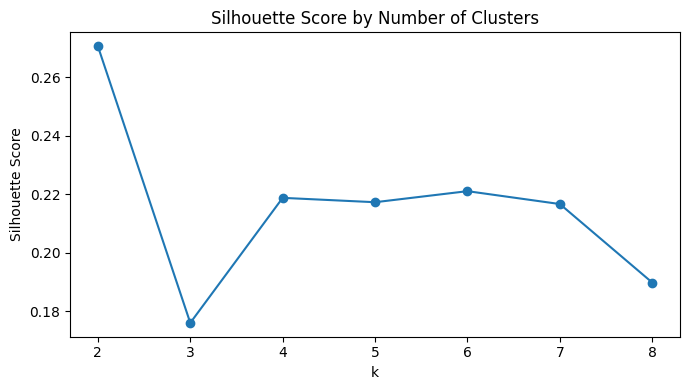

In [57]:
sil_scores = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores.append((k, sil))

sil_df = pd.DataFrame(sil_scores, columns=["k", "silhouette"])
print(sil_df)

plt.figure(figsize=(7,4))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

Fit final clustering

Pick the best kfrom the plot

In [58]:
best_k = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cl["cluster"] = kmeans.fit_predict(X)

print("Final silhouette:", silhouette_score(X, df_cl["cluster"]))

Final silhouette: 0.27064832877464967


**Explore the clusters thoroughly**

Cluster sizes

In [59]:
print(df_cl["cluster"].value_counts().sort_index())

cluster
0    11253
1     3747
Name: count, dtype: int64


Mean rating by cluster

cluster
1    1.886042
0    4.771972
Name: rating, dtype: float64


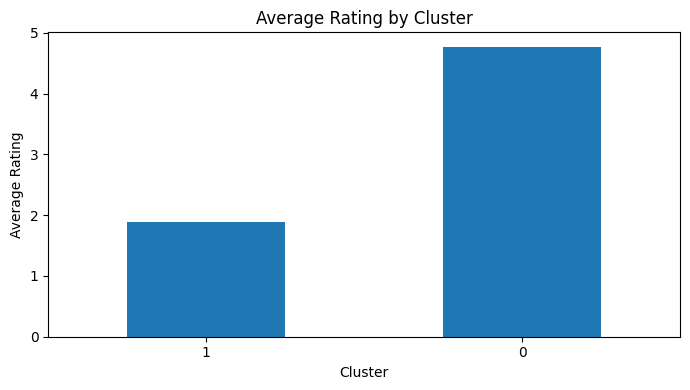

In [60]:
cluster_rating = df_cl.groupby("cluster")["rating"].mean().sort_values()
print(cluster_rating)

cluster_rating.plot(kind="bar", figsize=(7,4))
plt.title("Average Rating by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Model gender distribution by cluster

model_attr    Female  Female&Male      Male
cluster                                    
0           0.356172     0.326402  0.317426
1           0.345610     0.307179  0.347211


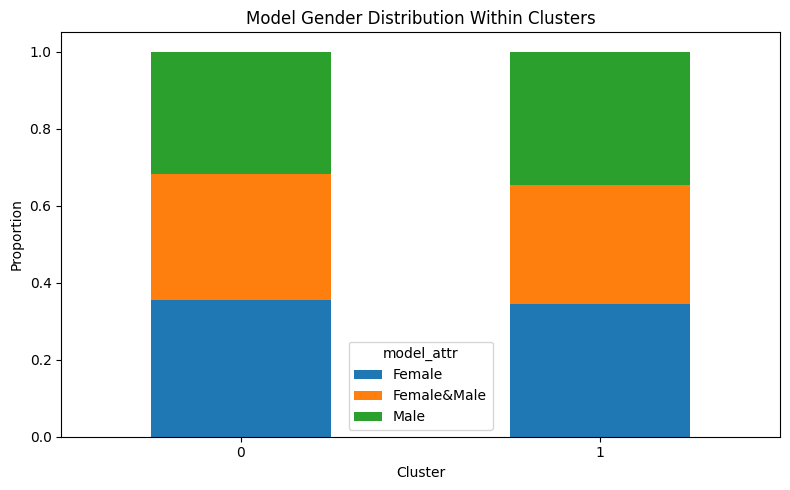

In [61]:
cluster_gender = pd.crosstab(df_cl["cluster"], df_cl["model_attr"], normalize="index")
print(cluster_gender)

cluster_gender.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Model Gender Distribution Within Clusters")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Category distribuition by cluster

In [62]:
cluster_category = pd.crosstab(df_cl["cluster"], df_cl["category"], normalize="index")
print(cluster_category.round(3))

category  Accessories & Supplies  Camera & Photo  Car Electronics & GPS  Computers & Accessories  Headphones  \
cluster                                                                                                        
0                          0.058           0.209                  0.032                    0.205       0.367   
1                          0.050           0.189                  0.029                    0.177       0.428   

category  Home Audio  Portable Audio & Video  Security & Surveillance  Television & Video  Wearable Technology  
cluster                                                                                                         
0              0.036                   0.065                    0.000               0.026                0.002  
1              0.044                   0.057                    0.001               0.022                0.003  


Brand distribution by cluster

In [63]:
for c in sorted(df_cl["cluster"].unique()):
    print(f"\nTop brands in cluster {c}:")
    print(df_cl[df_cl["cluster"] == c]["brand"].value_counts().head(10))


Top brands in cluster 0:
brand
Bose          1266
Logitech      1164
Sony           832
Mpow           680
EldHus         678
Fujifilm       575
Sennheiser     513
Etre Jeune     484
TaoTronics     477
Pyle           367
Name: count, dtype: int64

Top brands in cluster 1:
brand
Logitech      341
Bose          335
Mpow          240
JLAB          217
Sony          217
Pyle          213
Skullcandy    204
EldHus        182
Linksys       174
Sennheiser    170
Name: count, dtype: int64


**Compare with and without model gender**

This is important. It tells us whether gender contributes useful structure.

In [64]:
# Without model_attr
X_cat_no_gender = encoder.fit_transform(df_cl[["category", "brand"]])
X_no_gender = np.hstack([X_cat_no_gender, X_num])

sil_scores_no_gender = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_no_gender)
    sil = silhouette_score(X_no_gender, labels)
    sil_scores_no_gender.append((k, sil))

sil_no_gender_df = pd.DataFrame(sil_scores_no_gender, columns=["k", "silhouette_no_gender"])
compare_sil = sil_df.merge(sil_no_gender_df, on="k")
print(compare_sil)

   k  silhouette  silhouette_no_gender
0  2    0.270648              0.323101
1  3    0.175932              0.194684
2  4    0.218731              0.251887
3  5    0.217236              0.228506
4  6    0.221019              0.239765
5  7    0.216608              0.230796
6  8    0.189726              0.268531


# Clustering Results
Clustering reveals two main groups of products: high-rated and low-rated. However, these clusters are not strongly driven by category or brand, and including model gender does not significantly improve clustering structure. This suggests that while model gender influences ratings, it does so as a subtle effect rather than defining distinct product groups.

# In depth Causal Analysis

OLS with controls

In [65]:
import statsmodels.formula.api as smf

df_ca = df[["rating", "model_attr", "category", "brand"]].dropna().copy()

# Keep top brands for stability and interpretability
top_brands = df_ca["brand"].value_counts().head(50).index
df_ca = df_ca[df_ca["brand"].isin(top_brands)].copy()

# Set Male as reference group
df_ca["model_attr"] = pd.Categorical(
    df_ca["model_attr"],
    categories=["Male", "Female", "Female&Male"],
    ordered=False
)

print(df_ca.shape)
print(df_ca["model_attr"].value_counts())

(331120, 4)
model_attr
Female         116258
Female&Male    109528
Male           105334
Name: count, dtype: int64


In [66]:
ols_model = smf.ols(
    "rating ~ C(model_attr, Treatment(reference='Male')) + C(category) + C(brand)",
    data=df_ca
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     243.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:09:52   Log-Likelihood:            -5.6620e+05
No. Observations:              331120   AIC:                         1.133e+06
Df Residuals:                  331059   BIC:                         1.133e+06
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

Extract key coefficients cleanly

In [67]:
coef_table = ols_model.summary2().tables[1]

rows_of_interest = [
    "C(model_attr, Treatment(reference='Male'))[T.Female]",
    "C(model_attr, Treatment(reference='Male'))[T.Female&Male]"
]

print(coef_table.loc[rows_of_interest, ["Coef.", "Std.Err.", "t", "P>|t|", "[0.025", "0.975]"]])

                                                       Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
C(model_attr, Treatment(reference='Male'))[T.Fe...  0.083158  0.006961  11.945505  6.960931e-33  0.069514  0.096802
C(model_attr, Treatment(reference='Male'))[T.Fe...  0.135033  0.007265  18.586127  4.556218e-77  0.120793  0.149273


Compare raw vs controlled effects

In [68]:
raw_means = df_ca.groupby("model_attr")["rating"].mean()

raw_gap_female = raw_means["Female"] - raw_means["Male"]
raw_gap_both = raw_means["Female&Male"] - raw_means["Male"]

controlled_female = coef_table.loc[
    "C(model_attr, Treatment(reference='Male'))[T.Female]", "Coef."
]
controlled_both = coef_table.loc[
    "C(model_attr, Treatment(reference='Male'))[T.Female&Male]", "Coef."
]

print(f"Raw Female - Male gap: {raw_gap_female:.4f}")
print(f"Raw Female&Male - Male gap: {raw_gap_both:.4f}")
print(f"Controlled Female - Male effect: {controlled_female:.4f}")
print(f"Controlled Female&Male - Male effect: {controlled_both:.4f}")

Raw Female - Male gap: 0.1082
Raw Female&Male - Male gap: 0.1226
Controlled Female - Male effect: 0.0832
Controlled Female&Male - Male effect: 0.1350


/tmp/ipykernel_10727/4294061401.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw_means = df_ca.groupby("model_attr")["rating"].mean()


Robustness check: High rating as binary outcome

In [69]:
df_log = df_ca.copy()
df_log["high_rating"] = (df_log["rating"] >= 5).astype(int)

logit_model = smf.logit(
    "high_rating ~ C(model_attr, Treatment(reference='Male')) + C(category) + C(brand)",
    data=df_log
).fit(maxiter=200)

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.663017
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            high_rating   No. Observations:               331120
Model:                          Logit   Df Residuals:                   331059
Method:                           MLE   Df Model:                           60
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                 0.02631
Time:                        17:10:28   Log-Likelihood:            -2.1954e+05
converged:                       True   LL-Null:                   -2.2547e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

Odds ratios

In [70]:
logit_params = logit_model.params
odds_ratios = np.exp(logit_params)

or_rows = [
    "C(model_attr, Treatment(reference='Male'))[T.Female]",
    "C(model_attr, Treatment(reference='Male'))[T.Female&Male]"
]

print("Odds Ratios for 5-star outcome:")
print(odds_ratios.loc[or_rows])

Odds Ratios for 5-star outcome:
C(model_attr, Treatment(reference='Male'))[T.Female]         1.105622
C(model_attr, Treatment(reference='Male'))[T.Female&Male]    1.173692
dtype: float64


Plot controlled coefficients

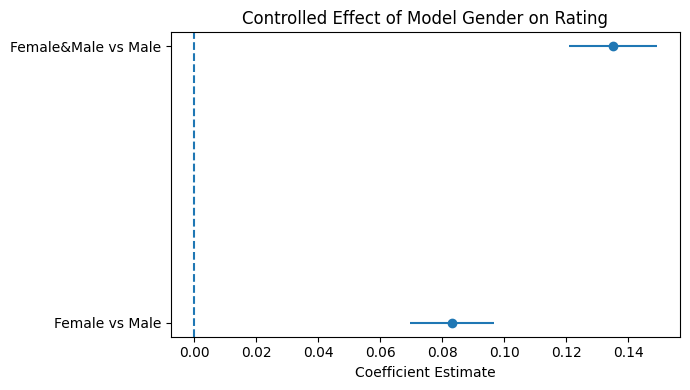

In [71]:
coef_plot = coef_table.loc[rows_of_interest, ["Coef.", "[0.025", "0.975]"]].copy()
coef_plot["label"] = ["Female vs Male", "Female&Male vs Male"]

plt.figure(figsize=(7,4))
plt.errorbar(
    coef_plot["Coef."],
    coef_plot["label"],
    xerr=[
        coef_plot["Coef."] - coef_plot["[0.025"],
        coef_plot["0.975]"] - coef_plot["Coef."]
    ],
    fmt="o"
)
plt.axvline(0, linestyle="--")
plt.title("Controlled Effect of Model Gender on Rating")
plt.xlabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

# Causal Analysis Results

Causal analysis shows that the effect of model gender on product ratings persists even after controlling for category and brand. Compared to male-presented products, products with female models receive an average rating increase of approximately 0.083 points, while products featuring both male and female models receive an increase of approximately 0.135 points, both of which are highly statistically significant (p < 0.001). Notably, these effects remain after accounting for product type and brand differences, indicating that they cannot be explained solely by observable product characteristics. A logistic regression further confirms these findings, showing that female-presented products have approximately 10.6% higher odds of receiving a 5-star rating, and mixed-gender products have approximately 17.4% higher odds. Together, these results provide strong evidence that model gender has a measurable and systematic influence on product ratings.

# **On my honor, I declare the following resources:**
1. Collaborators:
-

2. Web Sources:
- Homework 1 & 2 for EDA inspiration
- https://www.icwsm.org/2025/schedule/allpapers.html
- https://kdd2025.kdd.org/datasets-and-benchmarks-track-papers-2/
- https://pandas.pydata.org/?utm_source=chatgpt.com – for data cleaning and transformation
- https://scikit-learn.org/?utm_source=chatgpt.com – for clustering, preprocessing, and evaluation metrics
- https://www.statsmodels.org/?utm_source=chatgpt.com – for OLS regression setup and interpretation
- https://seaborn.pydata.org/?utm_source=chatgpt.com – for exploratory data analysis and plotting
- https://matplotlib.org/?utm_source=chatgpt.com – for visualizations used during EDA


3. AI Tools:
- chatGPT: Used to compare the three datasets for the Comparative Analysis of Datasets
- chatGPT: Used to help generate a EDA
- chatGPT: Provided with EDA results and asked to give observations, hypothesis, and potential RQs
- chatGPT: Used to debug code errors (e.g., OneHotEncoder parameter issues, model setup)

- chatGPT: Used to explain clustering evaluation metrics (e.g., silhouette score)

- chatGPT: Used to refine explanations of algorithmic decisions and interpretations

- chatGPT: Used to structure and polish written responses for clarity
